<div style="text-align: center;">
    <h1 style="font-size: 64px; 
               font-weight: 800;
               color: #1f0d4f;
               letter-spacing: 2px;
               margin: 40px 0;">
        LISTA 4
    </h1>
</div>

# Importy

In [ ]:
import matplotlib.pyplot as plt 
import numpy as np
import timeit
import sys
from __future__ import annotations
from array import array
from collections import deque
from typing import Iterator, Optional, TypeVar, Generic, Final
from collections import deque


# Ustawienie stylu wykresów
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# 1. Przeprowadź analizę eksperymentalną stosu zaimplementowanego przy pomocy listy jednokierunkowej

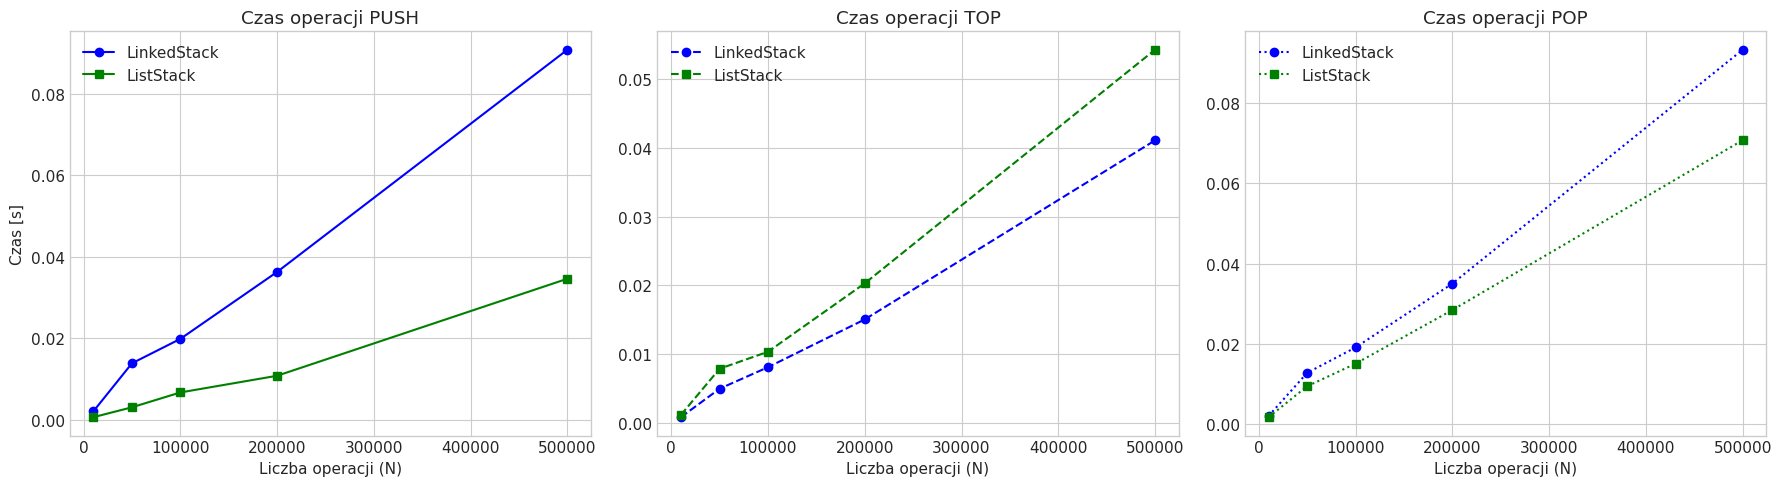

In [ ]:
# Implementacja za pomocą listy jednikierunkowej z wykładu
class Empty(Exception):
    pass

class LinkedStack:
    class _Node:
        __slots__ = '_element', '_next' 
        def __init__(self, element, next):
            self._element = element
            self._next = next
            
    def __init__(self):
        self._head = None
        self._size = 0
        
    def __len__(self):
        return self._size
    
    def is_empty(self):
        return self._size == 0
    
    def push(self, e):
        self._head = self._Node(e, self._head)
        self._size += 1
        
    def top(self):
        if self.is_empty(): raise Empty('Stack is empty!')
        return self._head._element
    
    def pop(self):
        if self.is_empty(): raise Empty('Stack is empty!')
        answer = self._head._element
        self._head = self._head._next
        self._size -= 1
        return answer
    
# Implementacja za pomocą zwykłej listy
class ListStack:
    def __init__(self):
        self.stack = []
    def push(self, element):
        self.stack.append(element)
    def pop(self):
        if self.isEmpty(): return "Stack is empty"
        return self.stack.pop()
    def peek(self):
        if self.isEmpty(): return "Stack is empty"
        return self.stack[-1]
    def isEmpty(self):
        return len(self.stack) == 0
    def size(self):
        return len(self.stack)

# Benchmark
def run_benchmark():
    # Zbiór wartości N
    test_sizes = [10_000, 50_000, 100_000, 200_000, 500_000]
    
    # Słowniki na wyniki
    results = {
        'linked_push': [], 'linked_top': [], 'linked_pop': [],
        'list_push': [],   'list_peek': [],  'list_pop': []
    }

    for N in test_sizes:
        # Testy implementacji za pomocą listy jednokierunkowej
        ls = LinkedStack()
        
        # 1. Push
        t_push_linked = timeit.timeit(lambda: [ls.push(x) for x in range(N)], number=1)
        
        # 2. Top
        t_top_linked = timeit.timeit(lambda: [ls.top() for _ in range(N)], number=1)

        # 3. Pop
        def pop_all_linked():
            while not ls.is_empty():
                ls.pop()
        t_pop_linked = timeit.timeit(pop_all_linked, number=1)

        # Test implementacjia za pomocą zwykłej listy
        lst = ListStack()
        
        # 1. Push
        t_push_list = timeit.timeit(lambda: [lst.push(x) for x in range(N)], number=1)
        
        # 2. Peek
        t_peek_list = timeit.timeit(lambda: [lst.peek() for _ in range(N)], number=1)
        
        # 3. Pop
        def pop_all_list():
            while not lst.isEmpty():
                lst.pop()
        t_pop_list = timeit.timeit(pop_all_list, number=1)

        # Zapisywanie wyników
        results['linked_push'].append(t_push_linked)
        results['linked_top'].append(t_top_linked)
        results['linked_pop'].append(t_pop_linked)
        results['list_push'].append(t_push_list)
        results['list_peek'].append(t_peek_list)
        results['list_pop'].append(t_pop_list)

    return test_sizes, results

# Wykresy
def plot_results(n_values, data):
    # Tworzymy 3 wykresy obok siebie
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Wykres 1: PUSH
    axes[0].plot(n_values, data['linked_push'], 'o-', label='LinkedStack', color='blue')
    axes[0].plot(n_values, data['list_push'], 's-', label='ListStack', color='green')
    axes[0].set_title('Czas operacji PUSH')
    axes[0].set_xlabel('Liczba operacji (N)')
    axes[0].set_ylabel('Czas [s]')
    axes[0].grid(True)
    axes[0].legend()

    # Wykres 2: TOP
    axes[1].plot(n_values, data['linked_top'], 'o--', label='LinkedStack', color='blue')
    axes[1].plot(n_values, data['list_peek'], 's--', label='ListStack', color='green')
    axes[1].set_title('Czas operacji TOP')
    axes[1].set_xlabel('Liczba operacji (N)')
    axes[1].grid(True)
    axes[1].legend()

    # Wykres 3: POP
    axes[2].plot(n_values, data['linked_pop'], 'o:', label='LinkedStack', color='blue')
    axes[2].plot(n_values, data['list_pop'], 's:', label='ListStack', color='green')
    axes[2].set_title('Czas operacji POP')
    axes[2].set_xlabel('Liczba operacji (N)')
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    n_values, benchmark_data = run_benchmark()
    plot_results(n_values, benchmark_data)

Na wszystkich wykresach widzimy liniową zależność czasu od liczby operacji $N$. Oznacza to, że obie implementację mają złożoność obliczeniową: $\mathcal{O}{(1)}$. Pomimo tego stała czasowa w przypadku linkedStack jest większa.

**Dla operacji Push:** większa stała czasowa dla LinkedStack wynika z faktu, że każde wywołanie push() tworzy dodatkowy obiekt _Node. Z kolei utworzenie tego obiektu wiąże się z alokacją pamięci, wywołaniem metody ```__init__``` i przypisaniem atrybutów (```self.elemnt``` oraz ```self._next```, co jest kosztowne). Z kolei dla implementacji stosu za pomocą listy polega jedynie na wpisaniu adresu obiektu dla zarezerwowanego wcześniej bloku pamięci (Lista w Pythonie to tablica dynamiczna napisana w C).

**Dla opercaji Top:** Jest to jedyna z trzech operacji, która nie modyfikuje struktury pamięci. Pomimo to stała czasowa w przypadku LinkedStack jest większa, bo trzeba wykonać dwa odczyty: ```self._head``` -> ```._element```.

**Dla operacji Pop:** LinkedStack jest wolniejsze, ponieważ gdy wykonujemy ```self._head = self._head._next``` tracimy referencję do starego węzła (za sprawą GC). Python musi wykryć, że obiekt jest niepotrzebny i zwolnić zajmowaną pamięć. Przy $N = 500 000$ oznacza to konieczność posprzątania pół miliona małych obiektów ```_Node```.

Ważnym czynnikiem spowalniającym odczyt danych z LinkedStack jest także fragmentacja pamięci. Każdy węzeł ```_Node``` jest osobnym bytem (albo kilkoma) w pamięci RAM. Każdy z tych Nodeów jest rozsiany w różnych miejscach pamięci, a CPU nie lubi skakać po pamięci. Z kolei lista wbudowana przchowuje wskażnik do elementów w jednym, ciągłym miejscu pamięci.

Spróbujmy zoptymalizować, niektóre z tych bottlenecków w stosie opartym na liście kierunkowej, jednocześnie nie wchodząc zbyt głęboko w szczegóły:

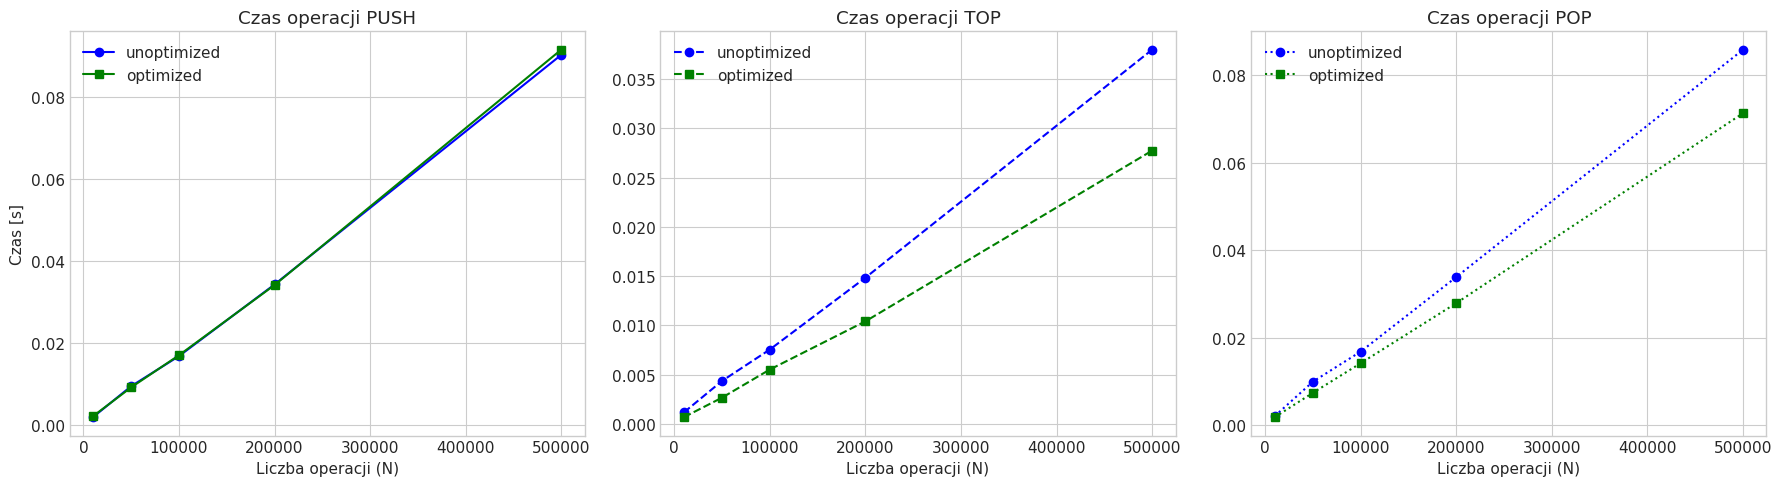

In [29]:
class Empty(Exception):
    pass

class OptimizedLinkedStack:
    __slots__ = '_head', '_size', '_free'
    
    class _Node:
        __slots__ = '_element', '_next'
        
        def __init__(self):
            self._element = None
            self._next = None
    
    def __init__(self):
        self._head = None
        self._size = 0
        self._free = None  # pula wolnych węzłów
    
    def __len__(self):
        return self._size
    
    def is_empty(self):
        return self._size == 0
    
    def push(self, e):
        if self._free is not None:
            # recykling węzła z puli
            node = self._free
            self._free = node._next
            node._element = e
            node._next = self._head
        else:
            # nowy węzeł tylko gdy pula pusta
            node = self._Node()
            node._element = e
            node._next = self._head
        self._head = node
        self._size += 1
    
    def top(self):
        if self._size == 0:
            raise Empty('Stack is empty!')
        return self._head._element
    
    def pop(self):
        if self._size == 0:
            raise Empty('Stack is empty!')
        node = self._head
        answer = node._element
        self._head = node._next
        # węzeł wraca do puli zamiast być zwalniany
        node._element = None
        node._next = self._free
        self._free = node
        self._size -= 1
        return answer
    
# Benchmark
def run_benchmark():
    # Zbiór wartości N
    test_sizes = [10_000, 50_000, 100_000, 200_000, 500_000]
    
    # Słowniki na wyniki
    results = {
        'unoptimized_push': [], 'unoptimized_top': [], 'unoptimized_pop': [],
        'optimized_push': [],   'optimized_top': [],  'optimized_pop': []
    }

    for N in test_sizes:
        # Testy implementacji za pomocą listy jednokierunkowej
        ls = LinkedStack()
        
        # 1. Push
        t_push_linked = timeit.timeit(lambda: [ls.push(x) for x in range(N)], number=1)
        
        # 2. Top
        t_top_linked = timeit.timeit(lambda: [ls.top() for _ in range(N)], number=1)

        # 3. Pop
        def pop_all_linked():
            while not ls.is_empty():
                ls.pop()
        t_pop_linked = timeit.timeit(pop_all_linked, number=1)

        # Test implementacjia za pomocą zwykłej listy
        lst = OptimizedLinkedStack()
        
        # 1. Push
        t_push_list = timeit.timeit(lambda: [lst.push(x) for x in range(N)], number=1)
        
        # 2. Peek
        t_peek_list = timeit.timeit(lambda: [lst.top() for _ in range(N)], number=1)
        
        # 3. Pop
        def pop_all_list():
            while not lst.is_empty():
                lst.pop()
        t_pop_list = timeit.timeit(pop_all_list, number=1)

        # Zapisywanie wyników
        results['unoptimized_push'].append(t_push_linked)
        results['unoptimized_top'].append(t_top_linked)
        results['unoptimized_pop'].append(t_pop_linked)
        results['optimized_push'].append(t_push_list)
        results['optimized_top'].append(t_peek_list)
        results['optimized_pop'].append(t_pop_list)

    return test_sizes, results

# Wykresy
def plot_results(n_values, data):
    # Tworzymy 3 wykresy obok siebie
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Wykres 1: PUSH
    axes[0].plot(n_values, data['unoptimized_push'], 'o-', label='unoptimized', color='blue')
    axes[0].plot(n_values, data['optimized_push'], 's-', label='optimized', color='green')
    axes[0].set_title('Czas operacji PUSH')
    axes[0].set_xlabel('Liczba operacji (N)')
    axes[0].set_ylabel('Czas [s]')
    axes[0].grid(True)
    axes[0].legend()

    # Wykres 2: TOP
    axes[1].plot(n_values, data['unoptimized_top'], 'o--', label='unoptimized', color='blue')
    axes[1].plot(n_values, data['optimized_top'], 's--', label='optimized', color='green')
    axes[1].set_title('Czas operacji TOP')
    axes[1].set_xlabel('Liczba operacji (N)')
    axes[1].grid(True)
    axes[1].legend()

    # Wykres 3: POP
    axes[2].plot(n_values, data['unoptimized_pop'], 'o:', label='unoptimized', color='blue')
    axes[2].plot(n_values, data['optimized_pop'], 's:', label='optimized', color='green')
    axes[2].set_title('Czas operacji POP')
    axes[2].set_xlabel('Liczba operacji (N)')
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    n_values, benchmark_data = run_benchmark()
    plot_results(n_values, benchmark_data)

# 4. Zaimplementuj drzewo binarne za pomocą reprezentacji tablicowej.

In [ ]:
T = TypeVar("T")
U = TypeVar("U")

class BinaryTree(Generic[T]):
    __slots__ = ('_data', '_size')

    _data: list[Optional[T]]
    _size: int

    def __init__ (self, capacity: int = 16) -> None:
        self._data = [None] * capacity
        self._size = 0

    @staticmethod
    def parent(i: int) -> int:
        """Rodzic węzła"""
        return (i - 1) >> 1 if i > 0 else -1

    @staticmethod
    def left(i: int) -> int:
        """Lewe dziecko"""
        return (i << 1) | 1
    
    @staticmethod
    def right(i: int) -> int:
        """Prawe dziecko"""
        return (i << 1) + 2
    
    # Pamięć

    def _grow(self, min_cap: int) -> None:
        """Podwaja pojemność, aż do pomieszczenia min_cap."""
        new_cap: int = len(self._data)
        while new_cap <= min_cap:
            new_cap <<= 1

        self._data.extend([None] * (new_cap - len(self._data)))

    @property
    def capacity(self) -> int:
        """Aktualna pojemność tablicy"""
        return len(self._data)
    
    def shrink_to_fit(self) -> None:
        """Zmniejsza tablicę do minimalnego rozmiatu"""
        if self.size == 0:
            self._data = [None] * 16
            return
        
        max_idx: int = self._max_index()
        new_cap: int = 16
        while new_cap <= max_idx:
            new_cap <<= 1
        self._data = self._data[:new_cap]

    def _max_index(self) -> int:
        "Ostatni niepusty indeks lub -1"
        data = self._data
        for i in range(len(data) - 1, -1, -1):
            if data[i] is not None:
                return i
        return -1
    
    # Dostęp

    def __len__(self) -> int:
        return self._size
    
    def __bool__(self) -> bool:
        return self._size > 0
    
    def exists(self, i: int) -> bool:
        """Czy węzeł o indeksie i istnieje"""
        return 0 <= i < len(self._data) and self._data[i] is not None

    def get(self, i: int) -> Optional[T]:
        """Zwraca wartość węzła lub None."""
        if 0 <= i < len(self._data):
            return self._data[i]
        return None
    
    def __getitem__(self, i: int) -> Optional[T]:
        return self.get(i)
    

    def set(self, i: int, value: T) -> None:
        """Ustawia wartość węzła i."""
        if i < 0:
            raise IndexError(f"Indeks musi być nieujemny: {i}")
        if i >= len(self._data):
            self._grow(i)
        
        data = self._data
        if data[i] is None:
            self._size += 1
        data[i] = value

    def __setitem__(self, i: int, value: T) -> None:
        self.set(i, value)

    def __delitem__(self, i: int) -> None:
        if 0 <= i < len(self._data):
            data = self._data
            old: Optional[T] = data[i]
            if old is not None:
                data[i] = None
                self._size -= 1
            return old
        return None

    def clear(self) -> None:
        """Usuwa wszystkie węzły."""
        self._data = [None] * len(self._data)
        self._size = 0

    def __contains__(self, value: int) -> bool:
        for v in self._data:
            if v is not None and v == value:
                return True
        return False
    
    # Wstawianie

    def set_root(self, value: T) -> None:
        """Ustawia korzeń."""
        self.set(0, value)

    def set_left(self, parent_i: int, value: T) -> None:
        """Ustawia lewe dziecko węzła parent_i."""
        self.set((parent_i << 1) | 1, value)

    def set_right(self, parent_i: int, value: T) -> None:
        """Ustawia prawe dziecko węzła parent_i."""
        self.set((parent_i << 1) + 2, value)

    def get_left(self, parent_i: int) -> Optional[T]:
        """Zwraca lewe dziecko węzła parent_i."""
        return self.get((parent_i << 1) | 1)

    def get_right(self, parent_i: int) -> Optional[T]:
        """Zwraca prawe dziecko węzła parent_i."""
        return self.get((parent_i << 1) + 2)

    def get_parent(self, i: int) -> Optional[T]:
        """Zwraca rodzica węzła i."""
        p: int = (i - 1) >> 1
        return self.get(p) if i > 0 else None
    

    def subtree(self, root_i: int) -> BinaryTree[T]:
        new_tree: BinaryTree[T] = BinaryTree()
        if not self.exists(root_i):
            return new_tree

        # BFS kopiowanie
        queue: deque[tuple[int, int]] = deque([(root_i, 0)])
        data = self._data
        cap: int = len(data)

        while queue:
            old_i, new_i = queue.popleft()
            new_tree.set(new_i, data[old_i])  # type: ignore[arg-type]

            old_left: int = (old_i << 1) | 1
            if old_left < cap and data[old_left] is not None:
                queue.append((old_left, (new_i << 1) | 1))

            old_right: int = (old_i << 1) + 2
            if old_right < cap and data[old_right] is not None:
                queue.append((old_right, (new_i << 1) + 2))

        return new_tree
    
    def preorder(self) -> list[T]:
        if self._data[0] is None:
            return []

        result: list[T] = []
        stack: list[int] = [0]
        data = self._data
        cap: int = len(data)

        while stack:
            i: int = stack.pop()
            result.append(data[i])  # type: ignore[arg-type]

            right_i: int = (i << 1) + 2
            if right_i < cap and data[right_i] is not None:
                stack.append(right_i)

            left_i: int = (i << 1) | 1
            if left_i < cap and data[left_i] is not None:
                stack.append(left_i)

        return result
    
    def inorder(self) -> list[T]:
        result: list[T] = []
        stack: list[int] = []
        data = self._data
        cap: int = len(data)
        current: int = 0

        while stack or (current < cap and data[current] is not None):
            while current < cap and data[current] is not None:
                stack.append(current)
                current = (current << 1) | 1

            if stack:
                current = stack.pop()
                result.append(data[current])  # type: ignore[arg-type]
                current = (current << 1) + 2

        return result


    def __str__(self) -> str:
        lines: list[str] = []
        self._build_str(0, "", True, lines, is_root=True)
        return "\n".join(lines) if lines else "(empty tree)"

    def _build_str(
        self,
        i: int,
        prefix: str,
        is_last: bool,
        lines: list[str],
        is_root: bool = False,
    ) -> None:
        if not self.exists(i):
            return

        if is_root:
            lines.append(str(self._data[i]))
            new_prefix = ""
        else:
            connector: str = "└── " if is_last else "├── "
            lines.append(prefix + connector + str(self._data[i]))
            new_prefix = prefix + ("    " if is_last else "│   ")

        left_i: int = (i << 1) | 1
        right_i: int = (i << 1) + 2
        has_left: bool = self.exists(left_i)
        has_right: bool = self.exists(right_i)

        if has_left:
            self._build_str(left_i, new_prefix, not has_right, lines)
        if has_right:
            self._build_str(right_i, new_prefix, True, lines)
    

# 2. Narysuj reprezentację binarną wyrażenia arytmetycznego:
$$ (((5+2) \cdot (2-1))/((2+9) + ((7-2) - 1)) \cdot 8) $$
w formule drzewa binarnego.


In [5]:
tree = BinaryTree()

tree.set_root("*") # i=0

tree.set_left(0, "/")
tree.set_right(0, "8")
tree.set_left(1, "*")
tree.set_right(1, "+")
tree.set_left(3, "+")
tree.set_right(3, "-")
tree.set_left(4, "+")
tree.set_right(4, "-")
tree.set_left(7, "5")
tree.set_right(7, "2")
tree.set_left(8, "2")
tree.set_right(8, "1")
tree.set_left(9, "2")
tree.set_right(9, "9")
tree.set_left(10, "-")
tree.set_right(10, "1")
tree.set_left(21, "7")
tree.set_right(21, "2")

print(tree)

*
├── /
│   ├── *
│   │   ├── +
│   │   │   ├── 5
│   │   │   └── 2
│   │   └── -
│   │       ├── 2
│   │       └── 1
│   └── +
│       ├── +
│       │   ├── 2
│       │   └── 9
│       └── -
│           ├── -
│           │   ├── 7
│           │   └── 2
│           └── 1
└── 8


# 3. Narysuj drzewo binarne $T$, które spełnia wszystkie z poniższych warunków:
* każdy wewnętrzny węzeł zawiera pojedynczą literę
* przejście w porządku ***preorder*** daje ```EXAMFUN```
* przejście w porządku ***inorder*** daje ```MAFXUEN```

In [11]:
tree = BinaryTree()

tree.set_root("E") 
tree.set_left(0, "X")
tree.set_right(0, "N") 
tree.set_left(1, "A") 
tree.set_right(1, "U") 
tree.set_left(3, "M")
tree.set_right(3, "F") 

print(tree)
print(f"inorder {tree.inorder()}")
print(f"preorder {tree.preorder()}")

E
├── X
│   ├── A
│   │   ├── M
│   │   └── F
│   └── U
└── N
inorder ['M', 'A', 'F', 'X', 'U', 'E', 'N']
preorder ['E', 'X', 'A', 'M', 'F', 'U', 'N']


# 5. Napisz metodę, która na wejściu przyjmuje drzewo wyprowadzenia jakiegoś wyrażenia matematycznego, a na wyjściu zwraca pochodną tego wyrażenia względem podanej zmiennej.

In [ ]:
def derivative(tree: BinaryTree, var: str) -> BinaryTree:
    result = BinaryTree()

    def copy_branch(src_idx: int, dest_idx: int):
        if not tree.exists(src_idx):
            return

        queue = deque([(src_idx, dest_idx)])
        
        while queue:
            s_i, d_i = queue.popleft()
            
            # Przepisujemy wartość
            val = tree.get(s_i)
            result.set(d_i, val)

            # Obsługa lewego dziecka
            s_left = tree.left(s_i)
            if tree.exists(s_left):
                # Obliczamy gdzie trafi lewe dziecko w drzewie wynikowym
                d_left = result.left(d_i)
                queue.append((s_left, d_left))

            # Obsługa prawego dziecka
            s_right = tree.right(s_i)
            if tree.exists(s_right):
                # Obliczamy gdzie trafi prawe dziecko w drzewie wynikowym
                d_right = result.right(d_i)
                queue.append((s_right, d_right))

    # 2. Główna rekurencyjna funkcja różniczkująca
    def diff_node(src_idx: int, dest_idx: int):
        val = tree.get(src_idx)
        
        if val is None:
            return

        # liście
        if not isinstance(val, str) or val not in ("+", "-", "*", "/", "^", "sin", "cos"):
            if val == var:
                result.set(dest_idx, 1)
            else:
                result.set(dest_idx, 0)
            return

        # operatory
        op = val
        src_left = tree.left(src_idx)
        src_right = tree.right(src_idx)
        
        dest_left = result.left(dest_idx)
        dest_right = result.right(dest_idx)

        # Reguły różniczkowania
        if op in ("+", "-"):
            result.set(dest_idx, op)
            diff_node(src_left, dest_left)
            diff_node(src_right, dest_right)

        elif op == "*":
            result.set(dest_idx, "+")
            
            # (f' * g)
            result.set(dest_left, "*")
            diff_node(src_left, result.left(dest_left))      # f'
            copy_branch(src_right, result.right(dest_left))  # g (kopia)
            
            # (f * g')
            result.set(dest_right, "*")
            copy_branch(src_left, result.left(dest_right))   # f (kopia)
            diff_node(src_right, result.right(dest_right))   # g'

        elif op == "/":
            result.set(dest_idx, "/")
            
            # Licznik (f'g - fg')
            result.set(dest_left, "-")
            
            num_left = result.left(dest_left)
            result.set(num_left, "*")
            diff_node(src_left, result.left(num_left))
            copy_branch(src_right, result.right(num_left))
            
            num_right = result.right(dest_left)
            result.set(num_right, "*")
            copy_branch(src_left, result.left(num_right))
            diff_node(src_right, result.right(num_right))
            
            # Mianownik (g^2)
            result.set(dest_right, "^")
            copy_branch(src_right, result.left(dest_right))
            result.set(result.right(dest_right), 2)

        elif op == "^":
            # (x^n)' = n * x^(n-1) * x'
            exponent = tree.get(src_right)
            
            result.set(dest_idx, "*")
            
            mul_node = dest_left
            result.set(mul_node, "*")
            result.set(result.left(mul_node), exponent) # n
            
            pow_node = result.right(mul_node)
            result.set(pow_node, "^")
            copy_branch(src_left, result.left(pow_node)) # x (kopia)
            
            # Zmniejszanie wykładnika
            try:
                new_exp = exponent - 1
            except TypeError:
                new_exp = 1 
            result.set(result.right(pow_node), new_exp) # n-1
            
            # Pochodna wewnętrzna
            diff_node(src_left, dest_right)

        elif op == "sin":
            result.set(dest_idx, "*")
            
            cos_node = dest_left
            result.set(cos_node, "cos")
            copy_branch(src_left, result.left(cos_node))
            
            diff_node(src_left, dest_right)

        elif op == "cos":
            result.set(dest_idx, "*")
            
            neg_node = dest_left
            result.set(neg_node, "*")
            result.set(result.left(neg_node), -1)
            
            sin_node = result.right(neg_node)
            result.set(sin_node, "sin")
            copy_branch(src_left, result.left(sin_node))
            
            diff_node(src_left, dest_right)

    # Uruchomienie
    if len(tree) > 0:
        diff_node(0, 0)
        
    return result

In [23]:
def sample_tree():
    # Tworzymy drzewo dla wyrażenia: x^2 + 3*x
    
    bt = BinaryTree()
    bt.set_root("+")
    
    # Lewa strona: x^2
    bt.set_left(0, "^")
    bt.set_left(1, "x")
    bt.set_right(1, 2)
    
    # Prawa strona: 3*x
    bt.set_right(0, "*")
    bt.set_left(2, 3)
    bt.set_right(2, "x")
    
    return bt

expr_tree = sample_tree()
print("Wyrażenie: x^2 + 3*x")
print(expr_tree)

# Obliczamy pochodną po 'x'
deriv_tree = derivative(expr_tree, "x")

print("Pochodna: 2*x + 3")
print(deriv_tree)

Wyrażenie: x^2 + 3*x
+
├── ^
│   ├── x
│   └── 2
└── *
    ├── 3
    └── x
Pochodna: 2*x + 3
+
├── *
│   ├── *
│   │   ├── 2
│   │   └── ^
│   │       ├── x
│   │       └── 1
│   └── 1
└── +
    ├── *
    │   ├── 0
    │   └── x
    └── *
        ├── 3
        └── 1
